# Генеративные модели: автоэнкодеры, GAN и диффузия

## Генеративный ИИ

**Генеративная модель** — это модель, которая учится описывать распределение данных $p_\text{data}(x)$ и после обучения способна порождать новые объекты, близкие по свойствам к исходным данным. Генеративные подходы различаются по идеологии: одни оптимизируют явную **функцию правдоподобия**, другие строят **состязательные** схемы. Три простые и важные семейства — автоэнкодеры, GAN и диффузионные модели.

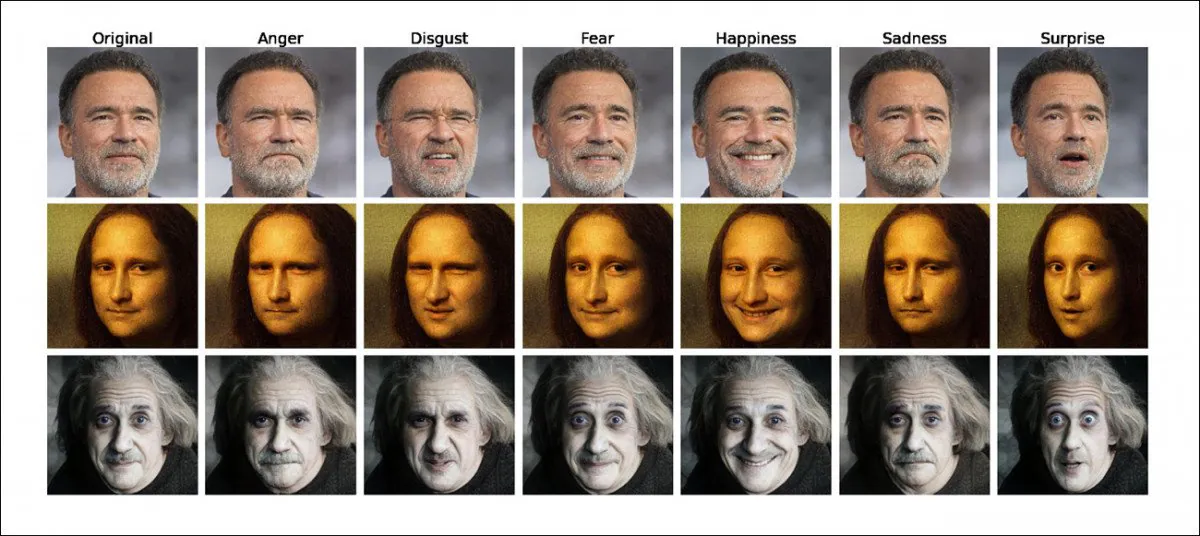

##Автоэнкодеры

###Концепция и формализация

**Автоэнкодер** $(autoencoder,\ AE)$ состоит из двух блоков: **энкодера** $(encoder,\ E)$ и **декодера** $(decoder,\ D)$. Энкодер переводит вход $x$ в представление $z = E(x)$ меньшей размерности, называемое **латентным вектором**. Это небольшой набор чисел, неким образом характеризующий вход. Декодер восстанавливает изображение из латентного вектора $\hat x = D(z)$.

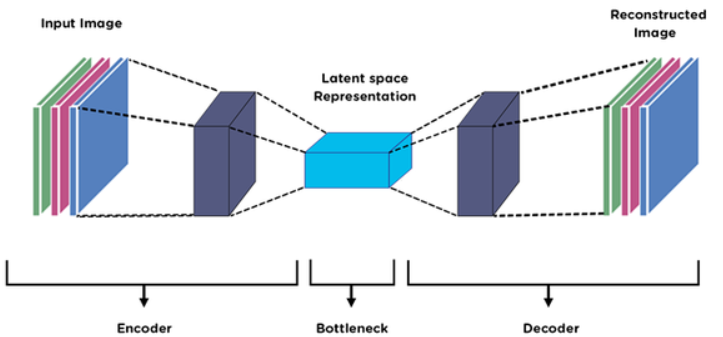

**Обучение** осуществляется путём минимизации функции восстановления, например среднеквадратичной ошибки:

$$L(\theta_E, \theta_D) = \frac{1}{N}\sum_{i=1}^N ||x^{i} - D(E(x^{i}))||_2^2$$

###Примеры применения

На **примере** ниже изображение цифры 7, то есть целое изображение из большого числа пикселей, сжали до компактного представления в виде 32 чисел, то есть латентного вектора, а затем развернули это представление в изображения исходного размера с использованием декодера.

Заметьте, что полученное изображение не содержит **шумов**.  `AE` часто используется для удаления шума или сжатия данных. Но с точки зрения генерации это существенный минус, так как результаты работы `AE` бывают нереалистичны.

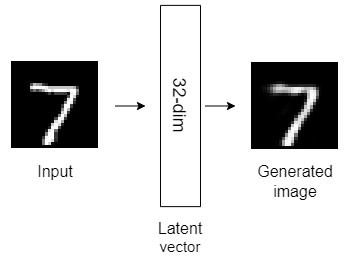

На вход и выход автоэнкодера можно подавать разные представления одного объекта. На **примере** ниже решается следующая задача. На **детектор** прилетают частицы, которые оставляют след в виде небольшого пятна. Частиц конечное количество, поэтому картина получается зашумлённой. Известна аналитическая непрерывная картина. Необходимо по данным с датчика предсказывать аналитический вариант.

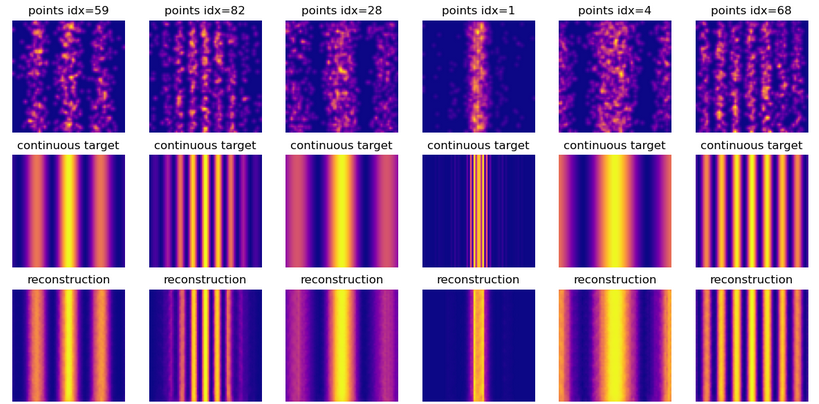

Видим, что энкодер с латентным вектором в 64 числа для изображений `64x64` превосходно справляется с задачей.

### Пример. Генерация изображений с кружочками




####Генерация данных

Создадим набор изображений `32x32` в градациях серого, где на фоне находятся кружки разного радиуса и яркости. После генерации данных реализуем свёрточный автоэнкодер и обучим его.

Импортируем основные библиотеки и зафиксируем рандом.

In [1]:
import numpy as np
from PIL import Image, ImageDraw
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(42)

Сгенерируем данные, 2000 экземпляров. С этими данными мы будем работать на протяжении всей лекции.

In [2]:
def make_circle_image(size, radius, cx, cy, intensity, background):
    img = Image.new("L", (size, size), int(255*background))
    draw = ImageDraw.Draw(img)
    bbox = [cx-radius, cy-radius, cx+radius, cy+radius]
    draw.ellipse(bbox, fill=int(255*intensity))
    return np.array(img, dtype=np.float32) / 255.0

def generate_circles(n, size=32, r_min=2, r_max=10):
    X = np.zeros((n, 1, size, size), dtype=np.float32)
    for i in range(n):
        r = np.random.randint(r_min, r_max+1)
        cx = np.random.randint(r, size-r)
        cy = np.random.randint(r, size-r)
        intensity = np.random.uniform(0.3, 1.0)
        bg = np.random.uniform(0.0, 0.1)
        X[i,0] = make_circle_image(size, r, cx, cy, intensity, bg)
    return X

X = generate_circles(2000)
ds = TensorDataset(torch.from_numpy(X))
loader = DataLoader(ds, batch_size=64, shuffle=True)

Выведем несколько примеров.

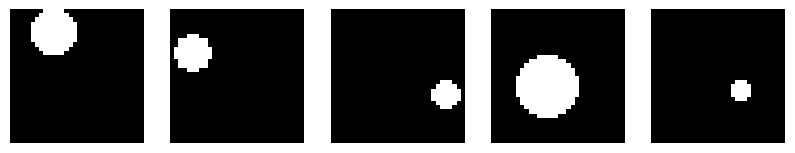

In [4]:
images = [X[i][0] for i in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for ax, img in zip(axes, images):
    ax.imshow(img, cmap='gray')
    ax.axis('off')
plt.show()

####Моделирование

Реализуем свёрточный автоэнкодер. Энкодер принимает на вход одноканальное изображение, применяет 16 фильтров свёртками `3x3`. Затем применяется `ReLU`, 16 каналов обрабатываются в 32 свёртками `3x3`. Результат развернём в латентный вектор небольшой размерности.

In [5]:
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*8*8, latent_dim)
        )
    def forward(self, x):
        return self.net(x)

Аналогично реализуем декодер, но из **обратных свёрток** $(transpose\ convolution)$, которые позволяют повышать размерность. На иллюстрации ниже пример работы обратной свёртки для перехода от изображения `2x2` к `3x3`.

trans_conv.svg

Для того чтобы границы кружков были чёткими, применяем сигмоиду на выходе.

In [6]:
class ConvDecoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32 * 8 * 8),
            nn.Unflatten(1, (32, 8, 8)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

Инициализируем модели и оптимизатор, он один общий для автоэнкодера, равного объединению энкодера и декодера.

Размер **латентного вектора** выберем равным 4, подразумевая, что для кодирования пятна достаточно знать координаты его центра по $x$ (+1) и $y$ (+1), радиус (+1) и ещё одно число для запаса, например для чёткости или формы (+1).

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
enc = ConvEncoder(4).to(device)
dec = ConvDecoder(4).to(device)
opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=1e-3)
loss_fn = nn.MSELoss()

Обучим модели.

In [10]:
from tqdm.auto import tqdm

loss_history = []
for epoch in tqdm(range(1, 1000 + 1)):
    total = 0.0
    for (xb,) in loader:
        xb = xb.to(device)
        z = enc(xb)
        xr = dec(z)
        loss = loss_fn(xr, xb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item() * xb.size(0)

    mean_loss = total / len(X)
    loss_history.append(mean_loss)
    if epoch < 10 or (not (epoch % 10) and 10 < epoch < 100) or \
        (not (epoch % 20) and 100 < epoch < 500) or \
        (not (epoch % 50) and 500 < epoch):
        print(f"Epoch {epoch}: loss={mean_loss:.6f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: loss=0.147566
Epoch 2: loss=0.053908
Epoch 3: loss=0.044116
Epoch 4: loss=0.041571
Epoch 5: loss=0.038619
Epoch 6: loss=0.033607
Epoch 7: loss=0.028561
Epoch 8: loss=0.023950
Epoch 9: loss=0.019882
Epoch 20: loss=0.012467
Epoch 30: loss=0.011116
Epoch 40: loss=0.010138
Epoch 50: loss=0.009403
Epoch 60: loss=0.008705
Epoch 70: loss=0.008160
Epoch 80: loss=0.007499
Epoch 90: loss=0.006971
Epoch 120: loss=0.005981
Epoch 140: loss=0.005466
Epoch 160: loss=0.005174
Epoch 180: loss=0.004790
Epoch 200: loss=0.004609
Epoch 220: loss=0.004389
Epoch 240: loss=0.004255
Epoch 260: loss=0.004222
Epoch 280: loss=0.004042
Epoch 300: loss=0.004046
Epoch 320: loss=0.004072
Epoch 340: loss=0.003856
Epoch 360: loss=0.003876
Epoch 380: loss=0.003800
Epoch 400: loss=0.003851
Epoch 420: loss=0.003640
Epoch 440: loss=0.003613
Epoch 460: loss=0.003878
Epoch 480: loss=0.003567
Epoch 550: loss=0.003488
Epoch 600: loss=0.003414
Epoch 650: loss=0.003681
Epoch 700: loss=0.003419
Epoch 750: loss=0.003330
E

#### Анализ результатов

Выведем график потерь в ходе обучения в двойном логарифмическом масштабе. Получили хорошую сходимость.

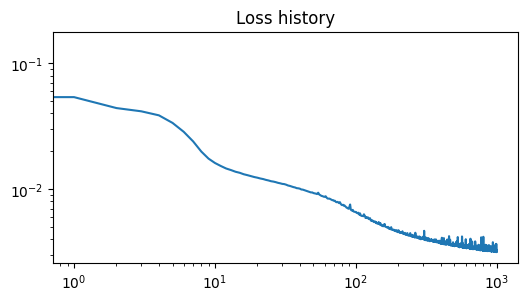

In [11]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.loglog(loss_history)
ax.set_title('Loss history')
plt.show()

Визуализируем несколько исходных изображений и их реконструкций:

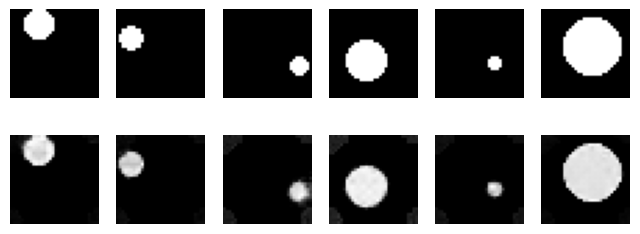

In [12]:
enc.eval()
dec.eval()

with torch.no_grad():
    xb = torch.from_numpy(X[:12]).to(device)
    xr = dec(enc(xb)).cpu().numpy()

plt.figure(figsize=(8,3))
for i in range(6):
    plt.subplot(2,6,i+1)
    plt.imshow(X[i,0], cmap='gray'); plt.axis('off')
    plt.subplot(2,6,6+i+1)
    plt.imshow(xr[i,0], cmap='gray'); plt.axis('off')
plt.show()

Результаты генерации хорошо соответстсвуют входам, но в этом же и проблема `AE`. Такие модели почти всегда учатся копировать поданные в них данные, то есть только переобучаются и почти неспособны создавать новое, что обычно нужно от генеративного ИИ. Например, между балериной и чашкой капучно для `AE` может быть лишь бессмысленный шум, а не некое гуманоидное существо. Ещё генерации автоэнкодера всегда мыльные, он не сохраняет исходные резкие контуры, что было видно по примеры с картинами прилета частиц на детектор.

## Генеративно-состязательные нейросети (GAN)

###Концепция

Идея **генеративно-состязательных сетей** $(Generative\ Adversarial\ Networks)$ была предложена Яном Гудфеллоу и его коллегами, в том числе Йошуа Бенжио, в 2014 году. Идея проста и глубока. Вместо того чтобы напрямую аппроксимировать распределение данных, как это делает автоэнкодер, мы строим две модели, которые соревнуются друг с другом: **генератор**, порождающий изображения из **шума**, и **дискриминатор**, отличающий реальные примеры от сгенерированных.

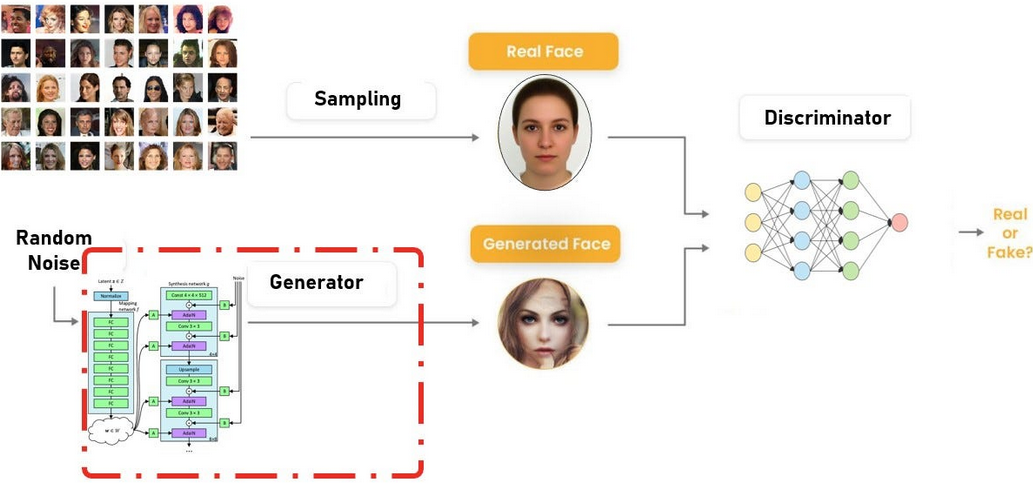

В результате обучения мы получаем **две модели**, причём результаты генератора могут быть значительно реалистичнее, чем выходы декодера в `AE`.

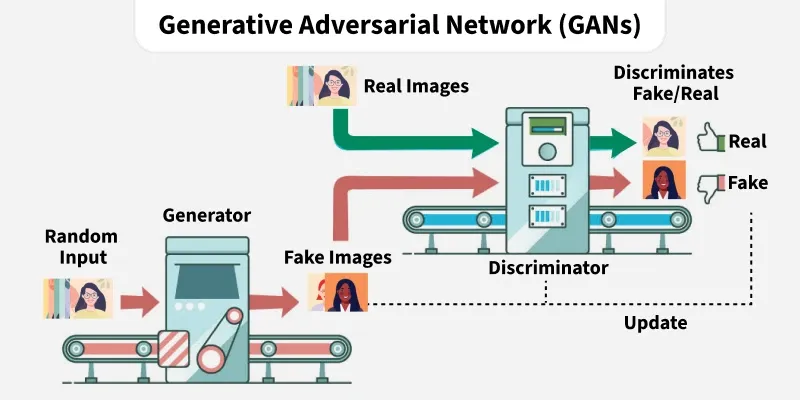

Генератор учится так, чтобы обмануть дискриминатор, а дискриминатор учится всё лучше отличать реальное от ложного, то есть они **состязаются**.

Это представляет собой **сложность**, так как часто либо дискриминатор слишком хорошо различает генерации и реальные объекты, либо генератор даёт слишком реалистиченые результаты. Для решения проблемы стоит вводить регуляризацию, выделять генератору или дискриминатору в отдельности большее число эпох в ходе обучения и т. д.


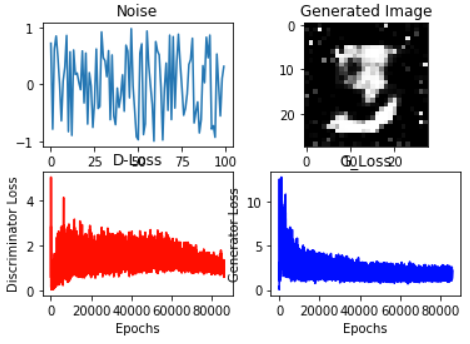

Существенный плюс `GAN` в интерпретируемости, когда мы можем определять некоторые направления в латентном пространстве и редактировать латентный вектор под наши нужды. На примере ниже управляемая генерация лиц моделью `InterFaceGAN`.

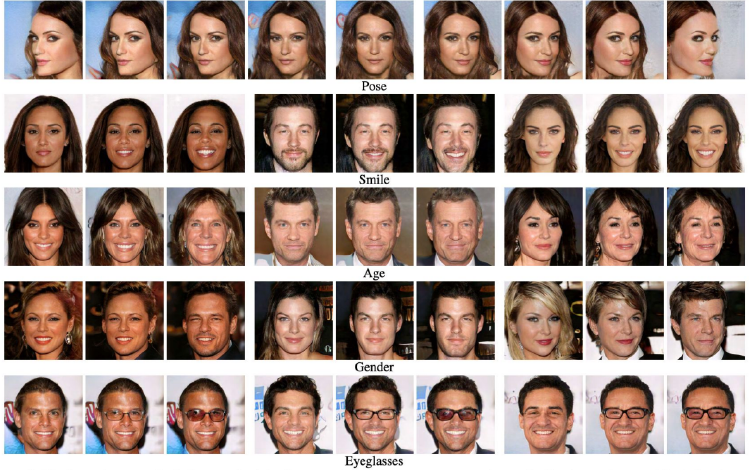

###Формализация

Дискриминатор предсказывает значения близкие к $1$ для настоящего объекта и близкие к $0$ для генерации. **Формально** обучение представляет собой задачу одновременной минимизации функции потерь генератора и максимизации потерь дискриминатора:

$$\min_G \max_D V(D,G) = \mathbb{E}_{x\sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z\sim p_z}[\log(1 - D(G(z)))]$$

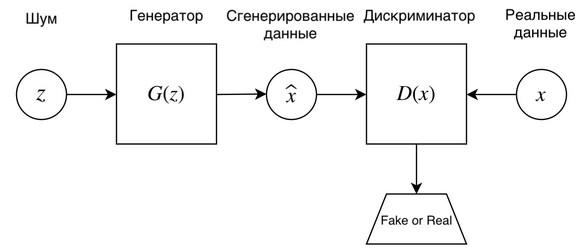

Под **максимизацией** имеется в виду, что значения потерь дискриминатора неположительные. Поэтому, например, потери на дискриминаторе $-0.3$ хуже, чем $-0.01$.

### Пример. Применение GAN к генерации кружков

####Моделирование

Решим **поставленную выше задачу** с использованием `GAN`. Загрузим данные.

In [13]:
dataset = TensorDataset(torch.from_numpy(X))
loader = DataLoader(dataset, batch_size=128, shuffle=True)

Реализуем глубокий свёрточный генератор, который получает на вход набор случайных чисел — шум. На их основе генератор будет отрисовывать изображения.

In [14]:
z_dim = 4

In [15]:
class Generator(nn.Module):
    def __init__(self, zdim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(zdim, 128*8*8),
            nn.ReLU(),
            nn.Unflatten(1, (128,8,8)),
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.Conv2d(32,1,3,padding=1),
            nn.Sigmoid()
        )
    def forward(self, z):
        return self.net(z)

Аналогично свёрточный дискриминатор, предсказывающий значение от $0$ до $1$.

In [16]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,4,2,1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32,64,4,2,1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(64*8*8, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

Инициализируем модели, оптимизаторы, функцию потерь.

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = Generator(z_dim).to(device)
D = Discriminator().to(device)
optG = torch.optim.Adam(G.parameters(), lr=1e-3, betas=(0.5,0.999))
optD = torch.optim.Adam(D.parameters(), lr=1e-3, betas=(0.5,0.999))
bce = nn.BCELoss()

Обучим модели. В коде есть комментарии, поясняющие, где и какую именно обучаем модель.

In [28]:
d_history = []
g_history = []

for epoch in tqdm(range(1, 1000 + 1)):
    for (xb,) in loader:
        xb = xb.to(device)
        bs = xb.size(0)

        # метки 0 и 1 для real и fake
        real = torch.ones(bs,1,device=device)
        fake = torch.zeros(bs,1,device=device)

        # ошибка дискриминатора на real
        out_real = D(xb)
        lossD_real = bce(out_real, real)

        # создаём латентные векторы, генерируем
        # изображения на их основе, считаем ошибку
        # дискриминатора
        z = torch.randn(bs, z_dim, device=device)
        x_fake = G(z)
        out_fake = D(x_fake.detach())
        lossD_fake = bce(out_fake, fake)

        # оптимизируем дискриминатор, чтобы он
        # лучше различал real и fake
        lossD = (lossD_real + lossD_fake) * 0.5
        optD.zero_grad()
        lossD.backward()
        optD.step()

        # аналогично обучаем генератор всё лучше
        # соответствовать real
        z = torch.randn(bs, z_dim, device=device)
        x_fake = G(z)
        out_fake = D(x_fake)
        lossG = bce(out_fake, real)

        optG.zero_grad()
        lossG.backward()
        optG.step()

    if epoch < 10 or (not (epoch % 10) and 10 < epoch < 100) or \
        (not (epoch % 20) and 100 < epoch < 500) or \
        (not (epoch % 50) and 500 < epoch):
        print(f"Epoch {epoch}: D={lossD.item():.4f}, G={lossG.item():.4f}")

    d_history.append(lossD.item())
    g_history.append(lossG.item())

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: D=0.2395, G=1.7307
Epoch 2: D=0.8624, G=1.4014
Epoch 3: D=0.7172, G=1.0889
Epoch 4: D=0.1281, G=2.2850
Epoch 5: D=1.5093, G=10.6571
Epoch 6: D=1.5167, G=0.6925
Epoch 7: D=0.5354, G=0.9018
Epoch 8: D=1.1380, G=0.4196
Epoch 9: D=0.3234, G=1.4442
Epoch 20: D=0.4265, G=2.3601
Epoch 30: D=0.1960, G=1.9861
Epoch 40: D=0.6191, G=0.8462
Epoch 50: D=0.6848, G=0.7594
Epoch 60: D=0.6145, G=0.7381
Epoch 70: D=0.6902, G=0.9208
Epoch 80: D=0.5516, G=0.9067
Epoch 90: D=0.6469, G=1.6775
Epoch 120: D=0.5893, G=1.1312
Epoch 140: D=0.5920, G=0.5044
Epoch 160: D=0.5891, G=1.0184
Epoch 180: D=0.5806, G=0.6210
Epoch 200: D=0.6141, G=1.4203
Epoch 220: D=0.6370, G=0.4444
Epoch 240: D=0.5983, G=0.5980
Epoch 260: D=0.7017, G=1.2703
Epoch 280: D=0.6054, G=1.2716
Epoch 300: D=0.6234, G=0.7688
Epoch 320: D=0.6130, G=0.5482
Epoch 340: D=0.6442, G=0.4722
Epoch 360: D=0.5646, G=0.8035
Epoch 380: D=0.5832, G=1.0323
Epoch 400: D=0.6052, G=0.8779
Epoch 420: D=0.6352, G=0.5039
Epoch 440: D=0.7420, G=1.0030
Epoch

На пятой эпохе потери на генераторе составили $10$, что много больше потерь в среднем по эпохам. Для большей информативности графиков ограничим значения сверху предельной величиной $4$.

In [31]:
g_history = np.clip(np.array(g_history), a_min=None, a_max=4)

Видим, что потери на генераторе сильно осциллируют. То же справедливо для дискриминатора, однако для него лучше виден общий тренд уменьшения потерь примерно от $0.6$ до $0.4$.

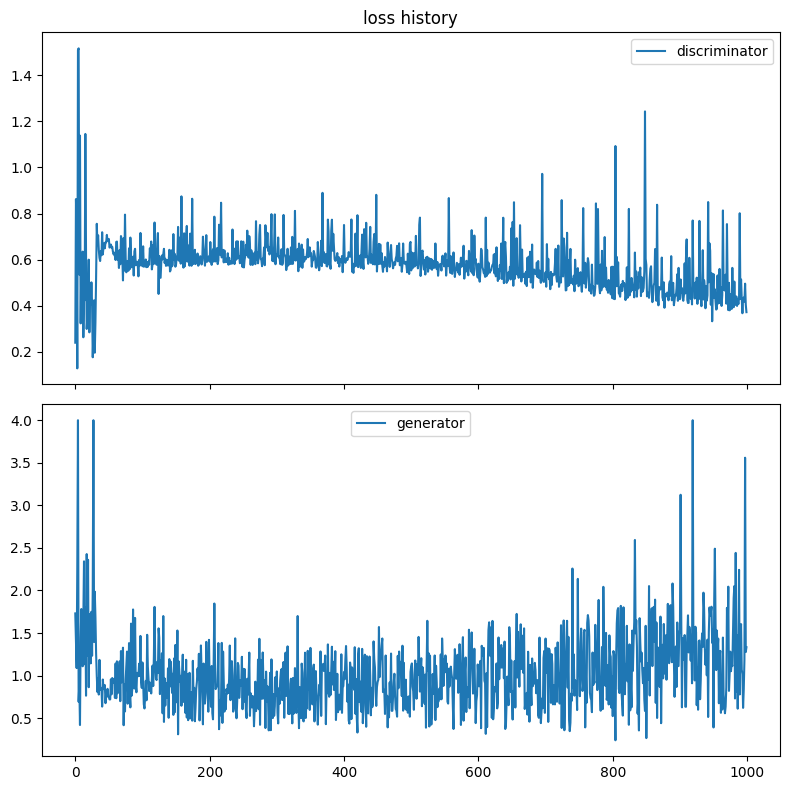

In [32]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(d_history, label='discriminator')
axs[0].set_title('loss history')
axs[0].legend()

axs[1].plot(g_history, label='generator')
axs[1].legend()

plt.tight_layout()
plt.show()

####Анализ результатов

Выведем несколько **примеров**. Выше мы увидели, что обучение `GAN` крайне нестабильно. Однако `GAN` обаладают лучшей способностью к генерации новых образцов, тогда как `AE` преимущественно способны лишь сжимать уже имеющиеся объекты в латентное представление. Ещё `GAN` не допустила размывания краёв, что говорит о реалистичности, но местами видны отклонения от округлой формы в сторону более сложной.

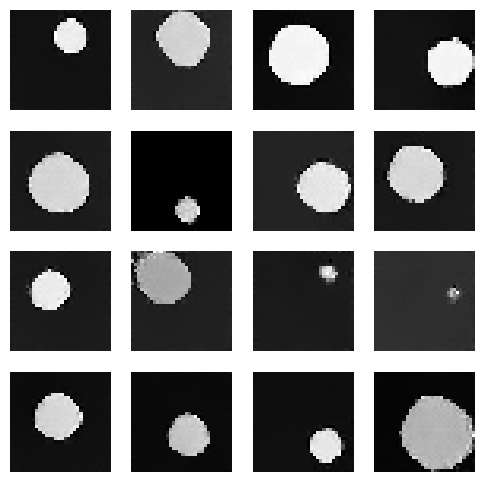

In [29]:
G.eval()
with torch.no_grad():
    z = torch.randn(16,z_dim,device=device)
    samples = G(z).cpu().numpy()
plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i,0], cmap='gray'); plt.axis('off')
plt.show()

### Коллапс моды

Важной проблемой `GAN` является **коллапс моды**. Это ситуация, когда генератор начинает для любого входа выдавать одну и ту же картинку, например усреднённое лицо или пятно, а дискриминатор понимает, что это ненастоящий образец, и работает с точностью 100%. Нас эта проблема не коснулась, однако попробуйте несколько других запусков или более простую архитектуру. С высокой вероятностью получите не разные кружочки, а одно серое пятно с одинаковыми неоднородностями.

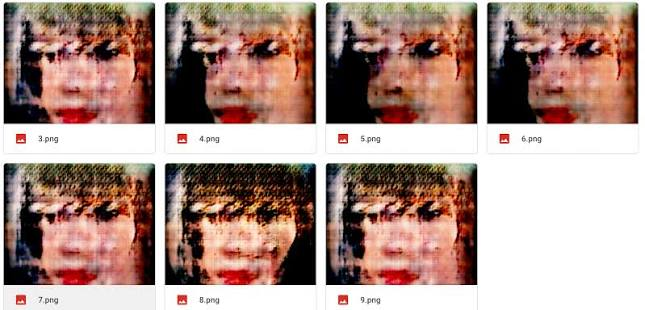

## Вариационные автоэнкодеры

**Вариационный автоэнкодер** $(Variational\ Autoencoder,\ VAE)$ — это автоэнкодер, в котором латентный вектор не задаётся одной точкой, а описывается **распределением**. Энкодер не просто сжимает объект в число или вектор, а предсказывает параметры распределения латентных векторов: **среднее** $\mu$ и характеристику разброса — **логарифм дисперсии** $\log \sigma^2$.

То есть энкодер не говорит, что $z$ — это такая-то точка в координатах $(5, 2)$, он говорит, что этот объект похож на область со средним $(5, 2)$ и разбросом $0.1$.

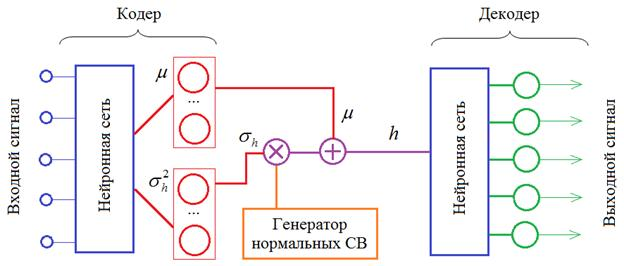

Таким образом, на выходе энкодер даёт не один латентный вектор, а целое семейство возможных латентных представлений. Затем из этого распределения выбирается случайный вектор $z$, который подаётся в декодер. Именно поэтому `VAE` умеет не только восстанавливать объекты, но и **генерировать новые**, поскольку латентное пространство становится гладким и структурированным.

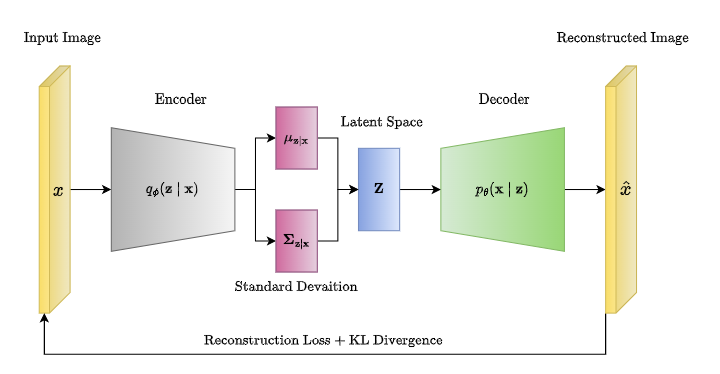

###Формализация

Пусть $x$ — входной объект. Энкодер c параметрами $\phi$ задаёт приближённое распределение:

$$q_\phi(z \mid x) = \mathcal{N}\left(\mu_\phi(x), \mathrm{diag}(\sigma_\phi^2(x))\right)$$

Вместо того чтобы брать детерминированный вектор, мы считаем, что скрытое представление $z$ объекта распределено по нормальному закону (график нормального распределения ниже), а ещё ни от чего не зависит, то есть это **априорное распределение**:

$$p(z) = \mathcal{N}(0, I)$$

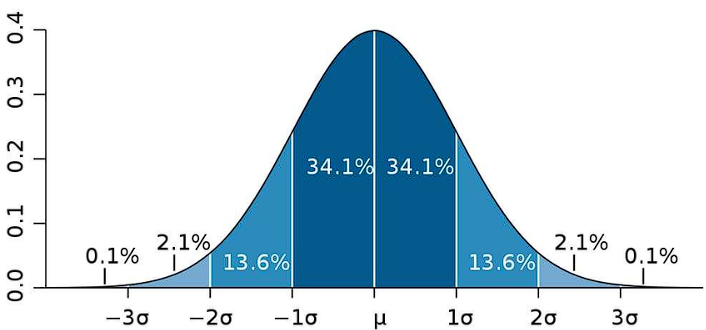

Декодер описывает вероятность восстановления объекта по латентному вектору. Вертикальная черта в аргументе функции говорит, что мы получаем объект $x$ при условии латентного представления $z$, индекс говорит, что мы делаем это с помощью модели с весами $\theta$:

$$p_\theta(x \mid z)$$

Обучение `VAE` сводится к максимизации нижней оценки правдоподобия, которая называется **ELBO**:

$$\mathcal{L}(\theta, \phi) = \mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)] - D_{KL}(q_\phi(z \mid x)\,||\,p(z)).$$

Первая часть показывает, насколько декодер правдоподобно генерирует $x$ при условии латентного вектора $z$. Она отвечает за **качество восстановления**. Вторая часть отвечает за то, чтобы латентное распределение, создаваемое $q_\phi(z \mid x)$, было близко к стандартному нормальному распределению $p(z)$.

###Проблема случайного выбора

Если энкодер выдаёт параметры распределения, возникает неудобство: как обучать сеть, если внутри есть случайная операция? Через случайный узел нельзя вычислить градиент, а все нейросети сейчас обучаются градиентными методами. Поэтому используется **трюк репараметризации** $(reparameterization\ trick)$. Пусть:

$$z \sim \mathcal{N}(\mu, \sigma^2).$$

Обозначим поэлементное умножение как $\odot$. Тогда можно записать:

$$z = \mu + \sigma \odot \varepsilon,\qquad \varepsilon \sim \mathcal{N}(0, I).$$

Случайность переносится в переменную $\varepsilon$, а $\mu$ и $\sigma$ остаются частью вычислительного графа. Благодаря этому градиент можно нормально распространить назад по всей сети.

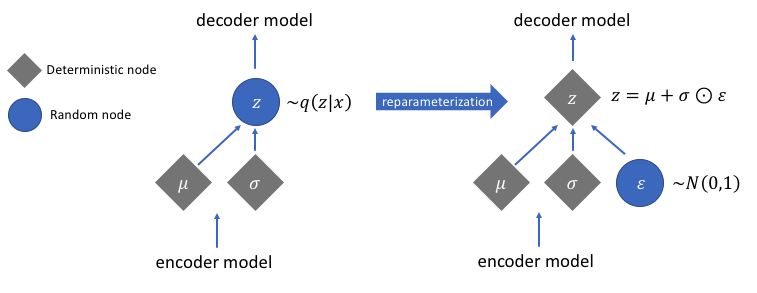

### Пример. Генерация изображений с кружочками

#### Подготовка данных

Загрузим уже подготовленный набор данных и создадим `DataLoader`.

In [33]:
dataset = TensorDataset(torch.from_numpy(X))
loader = DataLoader(dataset, batch_size=128, shuffle=True)

####Моделирование

Реализуем свёрточный `VAE`. Энкодер будет получать изображение и выдавать два вектора: `mu` и `logvar`. Первый задаёт среднее латентного распределения, второй — логарифм дисперсии. Латентное пространство всё так же выберем небольшим.

In [39]:
import torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=4):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(32 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(32 * 8 * 8, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 32 * 8 * 8)
        self.dec = nn.Sequential(
            nn.Unflatten(1, (32, 8, 8)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """
        Сеть предсказала mu и logvar. С их помощью
        вычисляем z, переходим от характеристик
        распределения к одному латентному вектору
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc_dec(z))
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        xr = self.decode(z)
        return xr, mu, logvar

Для понимания устройства сети может быть полезна `Sequence diagram` процесса.

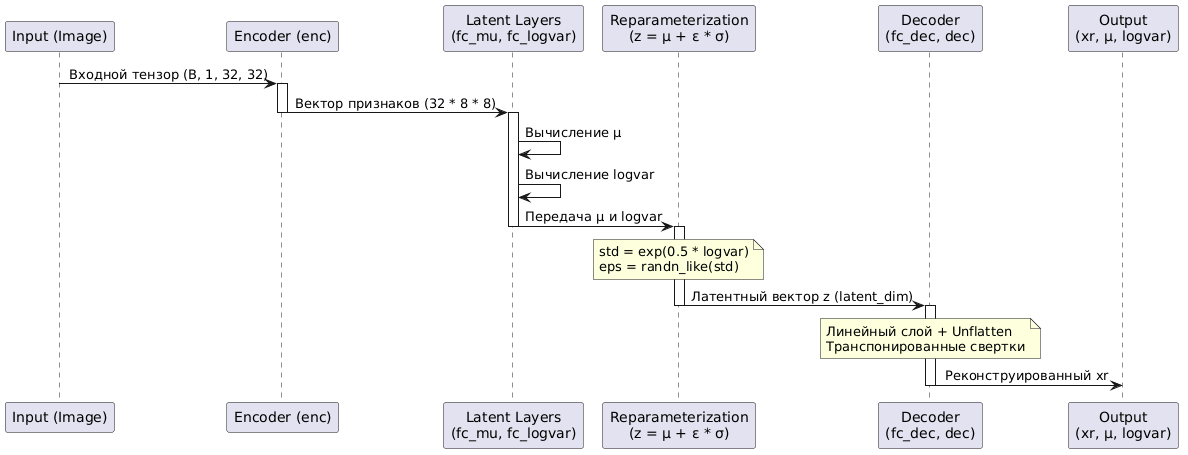

`UML`-код диаграммы:

```uml
@startuml
skinparam backgroundColor #FFFFFF
skinparam sequenceMessageAlign center

participant "Input (Image)" as X
participant "Encoder (enc)" as E
participant "Latent Layers\n(fc_mu, fc_logvar)" as P
participant "Reparameterization\n(z = μ + ε * σ)" as R
participant "Decoder\n(fc_dec, dec)" as D
participant "Output\n(xr, μ, logvar)" as Out

X -> E: Входной тензор (B, 1, 32, 32)
activate E
E -> P: Вектор признаков (32 * 8 * 8)
deactivate E

activate P
P -> P: Вычисление μ
P -> P: Вычисление logvar
P -> R: Передача μ и logvar
deactivate P

activate R
Note over R: std = exp(0.5 * logvar)\neps = randn_like(std)
R -> D: Латентный вектор z (latent_dim)
deactivate R

activate D
Note over D: Линейный слой + Unflatten\nТранспонированные свертки
D -> Out: Реконструированный xr
deactivate D

@enduml
```

####Функция потерь

Функция потерь состоит из двух частей: $MSE$ ошибки восстановления и `KL`-дивергенции между апостериорным распределением и стандартным нормальным распределением. Именно здесь появившиеся в модели среднее и дисперсия приобретают соответствующий математический смысл.

In [36]:
def vae_loss(xr, x, mu, logvar):
    recon = F.mse_loss(xr, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kld

Инициализируем модель, оптимизатор и устройство.

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvVAE(latent_dim=8).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

Обучим модель. Вариационные автоэнкодеры закономерно требуют более долгого обучения, поэтому выделим $2000$ эпох, в остальных случаях в этом ноутбуке $1000$.

In [46]:
from tqdm.auto import tqdm

loss_history = []
for epoch in tqdm(range(1, 2000 + 1)):
    total = 0.0
    for (xb,) in loader:
        xb = xb.to(device)
        xr, mu, logvar = model(xb)
        loss = vae_loss(xr, xb, mu, logvar)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    mean_loss = total / len(dataset)
    loss_history.append(mean_loss)

    if epoch < 10 or (not (epoch % 10) and 10 < epoch < 100) or \
        (not (epoch % 20) and 100 < epoch < 500) or \
        (not (epoch % 50) and 500 < epoch):
        print(f"Epoch {epoch}: loss={mean_loss:.6f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1: loss=188.641897
Epoch 2: loss=126.356697
Epoch 3: loss=86.475220
Epoch 4: loss=67.544929
Epoch 5: loss=58.753056
Epoch 6: loss=53.419288
Epoch 7: loss=49.153851
Epoch 8: loss=45.471598
Epoch 9: loss=42.338778
Epoch 20: loss=30.570304
Epoch 30: loss=27.897967
Epoch 40: loss=23.660079
Epoch 50: loss=20.991290
Epoch 60: loss=19.784231
Epoch 70: loss=19.220258
Epoch 80: loss=18.609904
Epoch 90: loss=18.330951
Epoch 120: loss=17.506567
Epoch 140: loss=17.131091
Epoch 160: loss=16.787997
Epoch 180: loss=16.587538
Epoch 200: loss=16.495989
Epoch 220: loss=16.285772
Epoch 240: loss=16.024555
Epoch 260: loss=15.910366
Epoch 280: loss=15.822849
Epoch 300: loss=15.702296
Epoch 320: loss=15.557110
Epoch 340: loss=15.628465
Epoch 360: loss=15.398724
Epoch 380: loss=15.416737
Epoch 400: loss=15.302003
Epoch 420: loss=15.164162
Epoch 440: loss=15.041649
Epoch 460: loss=15.011419
Epoch 480: loss=14.974284
Epoch 550: loss=14.712442
Epoch 600: loss=14.773929
Epoch 650: loss=14.527726
Epoch 700:

####Анализ результатов

Построим график потерь.

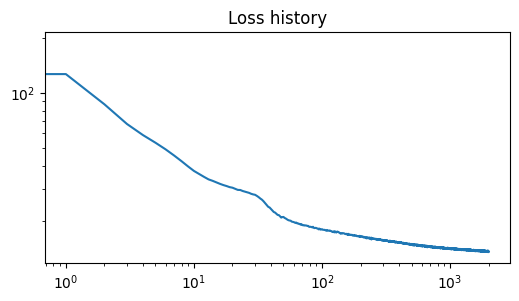

In [47]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.loglog(loss_history)
ax.set_title("Loss history")
plt.show()

Посмотрим на реконструкции.

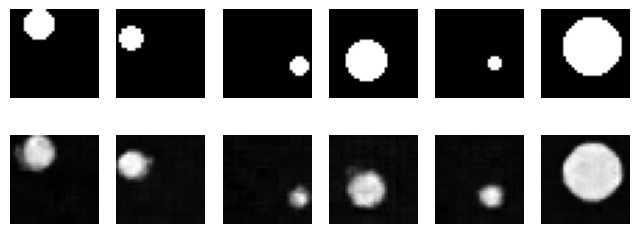

In [51]:
model.eval()

with torch.no_grad():
    xb = torch.from_numpy(X[:12]).to(device)
    xr, mu, logvar = model(xb)
    xr = xr.cpu().numpy()

plt.figure(figsize=(8, 3))
for i in range(6):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X[i, 0], cmap='gray')
    plt.axis('off')

    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(xr[i, 0], cmap='gray')
    plt.axis('off')
plt.show()

Реконструкции более размытые, чем те, что мы получили с `AE`. Однако `VAE` выдаёт не только саму генерацию, но и среднее латентного вектора со стандартным отклонением, чего не умеют другие модели.

### Семплирование новых объектов

Итак, главное отличие `VAE` от обычного автоэнкодера — возможность генерировать новые примеры, просто беря случайный вектор из стандартного нормального распределения и подавая его в декодер. Воспользуемся этим свойством.

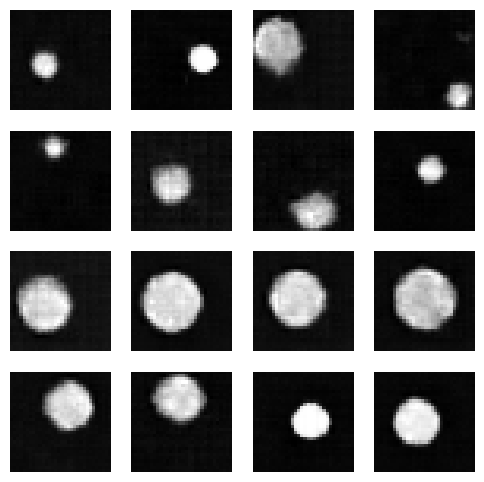

In [53]:
with torch.no_grad():
    z = torch.randn(16, 8, device=device)
    samples = model.decode(z).cpu().numpy()

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i, 0], cmap='gray')
    plt.axis('off')
plt.show()

## Диффузионные модели

### Концепция

**Диффузионная модель** (**$Diffusion\ Model$**) — это генеративная модель, которая учится постепенно **удалять шум** из данных. В отличие от `AE` и `GAN`, здесь генерация строится как последовательный процесс: сначала к объекту добавляется шум, а затем модель учится обращать этот процесс.

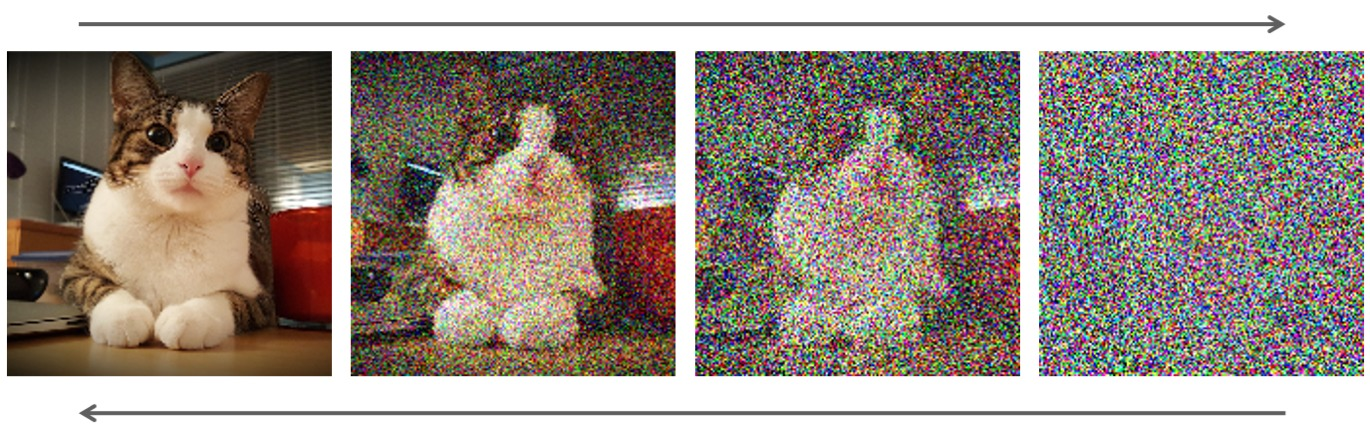

### Формализация

Пусть $x_0$ — исходное изображение. Процесс зашумления задаётся как пошаговое добавление шума из нормального распределения. То есть на каждом шаге мы изменяем каждый пиксель изображения на значение, близкое к нулю, и с меньшей вероятностью на сильно отличающееся от нуля. В итоге каждый пиксель изменяется на какую-то величину.

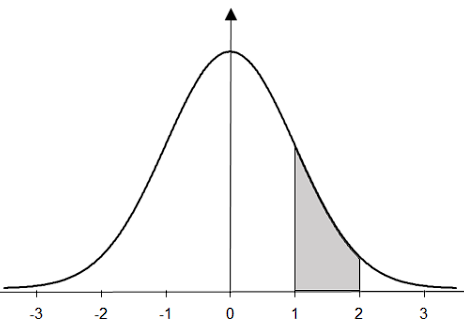

Пусть $q(x_t \mid x_{t-1})$ — это плотность распределения вероятности того, что состояние изображения $x_t$ получено из фиксированного предыдущего состояния $x_{t-1}$. Обозначим нормальное распределение как $\mathcal{N}$. $\beta_t \ll 1$ примем как маленький параметр шума на шаге $t$. Этот параметр позволяет масштабировать изменение до малой величины, например, до $10^{-2}$ или $10^{-4}$.

Ещё математика диктует, что мы должны переходить в состояние $x_t$ из чуть уменьшенного с учетом масштаба состояния $\sqrt{1-\beta_t}\,x_{t-1}$. Тогда итоговое выражение для плотности распределения вероятности перехода в состояние $x_t$:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\left(\sqrt{1-\beta_t}\,x_{t-1}, \beta_t I\right),$$

У параметра $\beta_t$ неспроста стоит индекс $t$. Обычно на первых шагах добавляют маленький шум, а потом больший по величине.

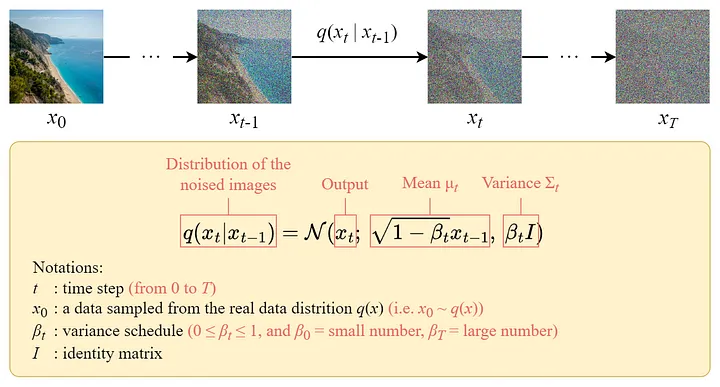

После нескольких шагов получаем практически чистый шум. Обозначим $\alpha_t = 1-\beta_t$. Тогда $t$ последовательных умножений $x_{t-1}$ на корни из этих коэффициентов $\sqrt{\alpha_t}$ аналогичны одному умножению $x_0$ на корень из произведения всех коэффициентов:

$$\bar\alpha_t = \alpha_1 \alpha_2...\alpha_t =  \prod_{s=1}^{t}\alpha_s.$$

Для удобства это можно записать напрямую:

$$q(x_t \mid x_0) = \mathcal{N}\left(\sqrt{\bar\alpha_t}\,x_0, (1-\bar\alpha_t)I\right),$$

Обратный процесс — это последовательное восстановление изображения из шума, именно это и делает **нейросеть**. Пусть $\varepsilon$ — некий добавленный шум, а $\varepsilon_\theta(x_t,t)$ — нейросеть, которая по зашумлённому изображению и номеру шага оценивает шум, добавленный на этом шаге. Тогда функция потерь:

$$L(\theta) = \mathbb{E}_{x_0,\varepsilon,t}\left[ \left\| \varepsilon - \varepsilon_\theta(x_t, t) \right\|_2^2 \right],$$

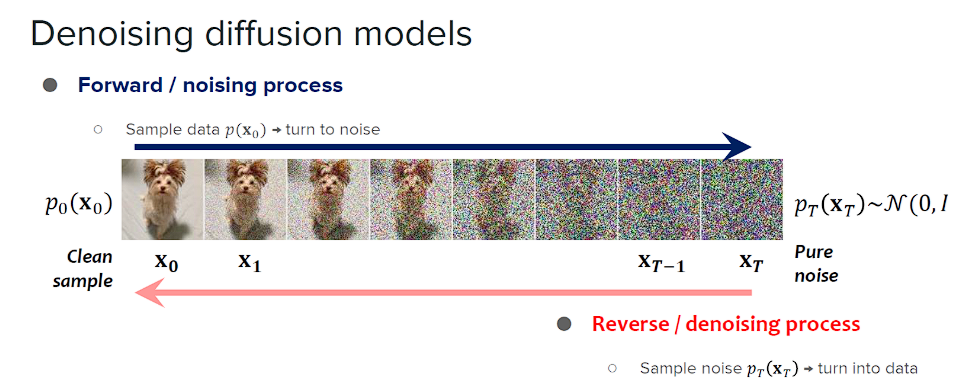

Идея диффузионной модели состоит в том, что сеть не пытается сразу сгенерировать картинку целиком, а учится делать маленький шаг очистки. За счёт этого обучение обычно оказывается более стабильным, чем в `GAN`.

### Пример. Генерация изображений с кружочками

Используем тот же набор изображений `32x32` в градациях серого, что и выше.

In [54]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

dataset = TensorDataset(torch.from_numpy(X))
loader = DataLoader(dataset, batch_size=128, shuffle=True)

#### Моделирование

Зададим линейное расписание шумов и функцию прямого зашумления. То есть масштаб изменения $\beta_t$ будет линейно увеличиваться от $10^{-4}$ до $2 \cdot 10^{-2}$ в течение $100$ шагов. Формула для изображения на $t$-м шаге:

$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

T = 100
betas = torch.linspace(1e-4, 2e-2, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise):
    sqrt_alpha_bar = torch.sqrt(alpha_bars[t])[:, None, None, None]
    sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bars[t])[:, None, None, None]
    return sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise

Реализуем свёрточную сеть, которая получает зашумлённое изображение и номер шага диффузии, а затем предсказывает шум. Используем синусоидальное позиционное кодирование для временных шагов $t$. Этот метод преобразует скалярные значения времени в векторы фиксированной размерности, используя комбинацию синусов и косинусов разных частот. Это позволяет нейросети понимать, на каком этапе диффузии находится входной тензор.

In [56]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        device = t.device
        emb_scale = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb

В этой архитектуре нейросети временной (определяющий шаг $t$) контекст подается через добавление синусоидальных эмбеддингов к выходам промежуточных слоев.

In [57]:
class DiffusionDenoiser(nn.Module):
    def __init__(self, time_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.time_proj1 = nn.Linear(time_dim, 32)
        self.time_proj2 = nn.Linear(time_dim, 32)

        self.net1 = nn.Conv2d(1, 32, 3, padding=1)
        self.net2 = nn.Conv2d(32, 32, 3, padding=1)
        self.net3 = nn.Conv2d(32, 32, 3, padding=1)
        self.net4 = nn.Conv2d(32, 1, 3, padding=1)
        self.act = nn.ReLU()

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        h = self.act(self.net1(x))
        h = h + self.time_proj1(t_emb)[:, :, None, None]
        h = self.act(self.net2(h))
        h = h + self.time_proj2(t_emb)[:, :, None, None]
        h = self.act(self.net3(h))
        return self.net4(h)

Инициализируем модель, оптимизатор и функцию потерь.

In [58]:
model = DiffusionDenoiser().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
print(model)

DiffusionDenoiser(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
  )
  (time_proj1): Linear(in_features=64, out_features=32, bias=True)
  (time_proj2): Linear(in_features=64, out_features=32, bias=True)
  (net1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (net2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (net3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (net4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (act): ReLU()
)


Обучение сводится к тому, что на каждом шаге мы берём изображение, выбираем случайный момент диффузии, зашумляем его и просим модель восстановить добавленный шум. Обучение можно проводить больше $500$ эпох, но это не даёт прироста качества генерации.

In [ ]:
loss_history = []

for epoch in tqdm(range(1, 501)):
    total = 0.0
    for (xb,) in loader:
        xb = xb.to(device)
        bs = xb.size(0)

        t = torch.randint(0, T, (bs,), device=device)
        noise = torch.randn_like(xb)
        x_t = q_sample(xb, t, noise)

        pred_noise = model(x_t, t.float())
        loss = loss_fn(pred_noise, noise)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item() * bs

    mean_loss = total / len(dataset)
    loss_history.append(mean_loss)

    if epoch < 10 or (not (epoch % 10) and epoch < 100) or (not (epoch % 20) and epoch >= 100):
        print(f"Epoch {epoch}: loss={mean_loss:.6f}")

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1: loss=0.732917
Epoch 2: loss=0.306035
Epoch 3: loss=0.227058
Epoch 4: loss=0.186217
Epoch 5: loss=0.166780
Epoch 6: loss=0.150564
Epoch 7: loss=0.135911
Epoch 8: loss=0.126659
Epoch 9: loss=0.118946
Epoch 10: loss=0.109589
Epoch 20: loss=0.076450
Epoch 30: loss=0.061279
Epoch 40: loss=0.053516
Epoch 50: loss=0.049486
Epoch 60: loss=0.045011
Epoch 70: loss=0.044367
Epoch 80: loss=0.040685
Epoch 90: loss=0.039412
Epoch 100: loss=0.037600
Epoch 120: loss=0.038289
Epoch 140: loss=0.034477
Epoch 160: loss=0.033109
Epoch 180: loss=0.031905
Epoch 200: loss=0.032409
Epoch 220: loss=0.030464
Epoch 240: loss=0.030437
Epoch 260: loss=0.028720
Epoch 280: loss=0.028921
Epoch 300: loss=0.027779
Epoch 320: loss=0.027798
Epoch 340: loss=0.027842
Epoch 360: loss=0.026968
Epoch 380: loss=0.026227
Epoch 400: loss=0.026887
Epoch 420: loss=0.025555
Epoch 440: loss=0.025474
Epoch 460: loss=0.025193
Epoch 480: loss=0.025131
Epoch 500: loss=0.025291


#### Анализ результатов

Построим график потерь в логарифмическом масштабе.

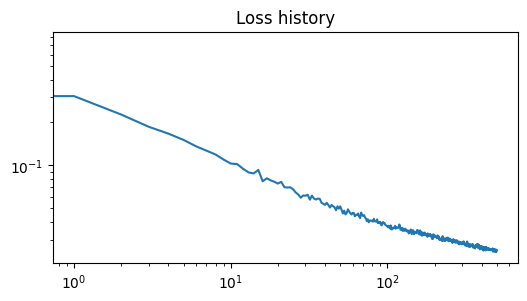

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.loglog(loss_history)
ax.set_title("Loss history")
plt.show()

Покажем, как исходное изображение превращается в шум при росте номера шага.

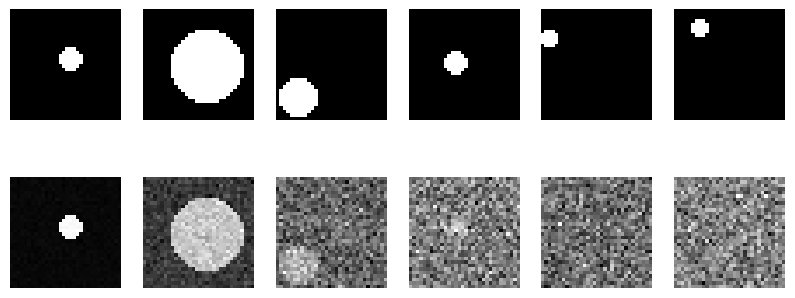

In [ ]:
model.eval()

with torch.no_grad():
    xb = torch.from_numpy(X[:6]).to(device)
    steps = torch.tensor([0, 10, 25, 50, 75, 99], device=device)
    noise = torch.randn_like(xb)
    x_noised = q_sample(xb, steps, noise).cpu().numpy()

plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X[i, 0], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(x_noised[i, 0], cmap="gray")
    plt.axis("off")
plt.show()

Сгенерируем новые изображения, начиная с чистого шума и последовательно удаляя его.

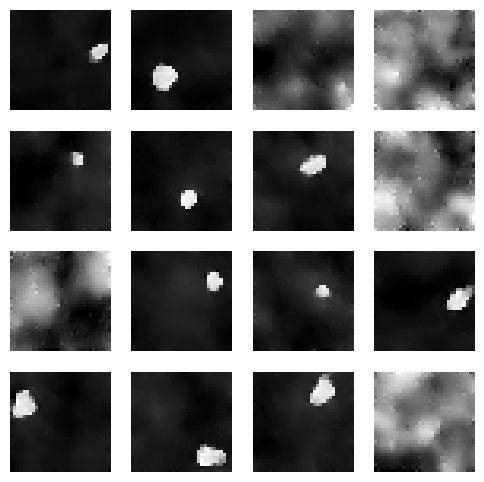

In [ ]:
@torch.no_grad()
def sample_images(model, n=16):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        pred_noise = model(x, t_batch.float())

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        x = (x - beta_t / torch.sqrt(1.0 - alpha_bar_t) * pred_noise) / torch.sqrt(alpha_t)

        if t > 0:
            x = x + torch.sqrt(beta_t) * torch.randn_like(x)

    return x.clamp(0.0, 1.0).cpu().numpy()


samples = sample_images(model, 16)

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i, 0], cmap="gray")
    plt.axis("off")
plt.show()

## Сравнение подходов в генеративном ИИ

Видим, что задача генерации кружочков тяжела для диффузионной модели. Попробуйте разные запуски. Нейросеть будет пытаться отрисовать несколько кружочков на одном изображении, дискриминатор `GAN` ограничивал бы такое поведение. Также диффузионная модель выдаёт равномерно распределённые серые пиксели, не понимая, что нужно чётко выделить объект и окружающую его пустоту при генерации из шума. Ещё относительно `AE` мы теряем качество, относительно `GAN` теряем интерпретируемость на уровне латентного вектора. Более того, диффузионные модели крайне затратны по вычислениям.

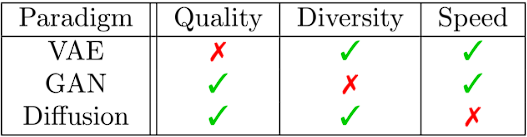

С другой стороны, диффузионная модель показывает стабильность при обучении и возможность генерации новых примеров, чего одновременно нет у `GAN` и `AE`. Ещё диффузионные модели не выдают мыльные картинки с плавными контурами, потому что идейно состоят в удалении шума, чем превосходят `VAE`. Эксперименты показывают, что рассматриваемая архитектура лучше работает с деталями и сложными композициями при больших объемах данных, в подтверждение тому `DALL-E` версий 2 и 3, `Midjourney` и `Stable Diffusion`. На 2026 год диффузия является де-факто стандартом для генерации изображений.

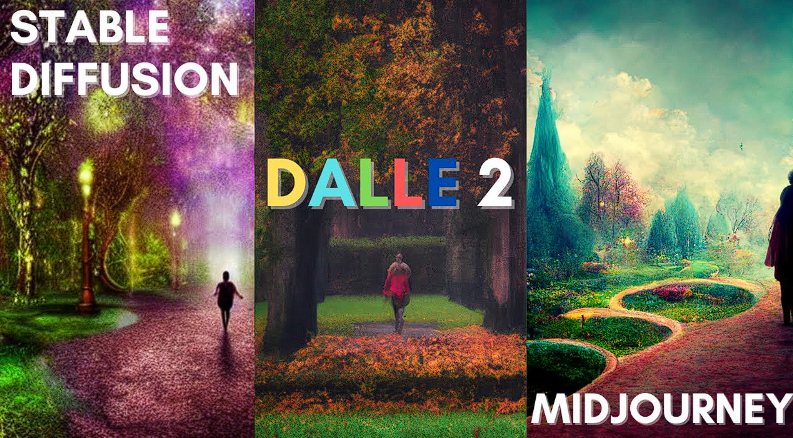

Отдельно отметим, что в первой версии `DALL-E` был использован `VAE`, а `Stable Diffusion` до сих пор использует `VAE`-энкодер для сжатия входного изображения в компактное представление, что позволяет снизить расходы видеопамяти в 8 раз. В завершение приведём схему с рассмотренными за занятие архитектурами.

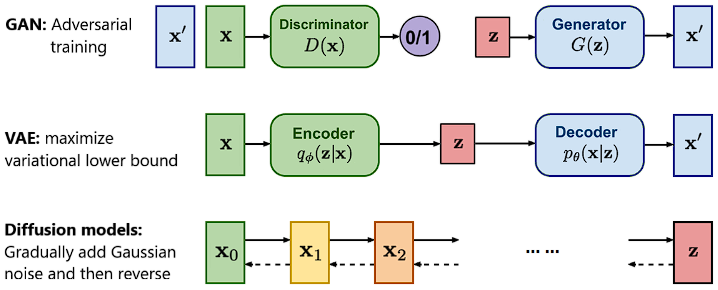

##Выводы

В ходе занятия мы:

1. Познакомились с генеративным ИИ.
2. Изучили концепцию автоэнкодера и формализовали задачу.
3. Привели примеры автоэнкодеров.
4. Реализовали глубокий свёрточный автоэнкодер для работы с изображениями пятен.
5. Познакомились с концепцией `GAN` и формализовали задачу.
6. Реализовали `GAN` для задачи с кружочками.
7. Подробно описали математические основы `VAE`
8. Предложили решение задачи с кружочками через `VAE`.
7. Изучили математические основы диффузионных моделей.
8. Решили задачу с кружочками через диффузию.
9. Проанализировали разные подходы в современном генеративном ИИ.

##Данные об авторе

Зюков Алексей Алексеевич,

лаборант отдела-онлайн образования НИЯУ МИФИ,

бакалавр кафедры суперкомпьютерных технологий в инженерно-физическом моделировании НИЯУ МИФИ.

##Список использованной и рекомендованной литературы

1. Егоров, А. Д. Репозитории с лекциями по анализу данных в НИЯУ МИФИ. – Текст : электронный / А. Д. Егоров // GitHub : [сайт]. – URL: https://github.com/ShadarRim (дата обращения: 01.11.2025).
2. Елистратова, Е. Variational Autoencoder (VAE). — Текст : электронный / Евгения Елистратова ; Яндекс Образование. — URL: https://education.yandex.ru/handbook/ml/article/variational-autoencoder-(vae) (дата обращения: 01.11.2025).
3. Захаров Е., Волхонский Д. Генеративно-состязательные сети (GAN). – Текст : электронный / Егор Захаров, Волхонский Денис ; Яндекс.Образование. – URL: https://education.yandex.ru/handbook/ml/article/generativno-sostyazatelnye-seti-(gan) (дата обращения: 01.11.2025).
4. Котельников, А. Диффузионные модели. — Текст : электронный / Аким Котельников ; Яндекс Образование. — URL: https://education.yandex.ru/handbook/ml/article/diffuzionnye-modeli (дата обращения: 01.11.2025).
5. Малов, Д. А. Глубокое обучение и анализ данных : практическое руководство. / Д. А. Малов. – Текст : непосредственный. – Санкт-Петербург : БХВ-Петербург, 2023. – 272 с. : ил. – ISBN 978-5-9775-1172-8.
6. Bond-Taylor, S. Deep Generative Modelling: A Comparative Review of VAEs, GANs, Normalizing Flows, Energy-Based and Autoregressive Models. — Текст : электронный / S. Bond-Taylor, A. Leach, Y. Long [et al.] // arXiv.org : [сайт]. — 2021. — URL: https://arxiv.org/abs/2005.09635 (дата обращения: 01.11.2025).
7. PyTorch Examples. VAE : официальная документация PyTorch. — Текст : электронный // GitHub : [сайт]. — URL: https://github.com/pytorch/examples/blob/main/vae/main.py (дата обращения: 01.11.2025).
